In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision


In [6]:
import torchvision.datasets as datasets
import torchvision.transforms as transforms

# 1. Define transformation
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

# 2. Download and load data
train_dataset = datasets.MNIST(root='./data1', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root='./data1', train=False, download=True, transform=transform)


100%|███████████████████████████████████████| 9.91M/9.91M [00:17<00:00, 580kB/s]
100%|██████████████████████████████████████| 28.9k/28.9k [00:00<00:00, 89.4kB/s]
100%|███████████████████████████████████████| 1.65M/1.65M [00:05<00:00, 305kB/s]
100%|██████████████████████████████████████| 4.54k/4.54k [00:00<00:00, 2.16MB/s]


In [5]:
from torch.utils.data import DataLoader


In [7]:
trainloader = DataLoader(train_dataset, batch_size=64, shuffle=True)
testloader = DataLoader(test_dataset, batch_size=64)

In [8]:
import torch.nn as nn

class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()

        self.conv_layer = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),  # Fixed: 1 input channel
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )

        self.fc_layers = nn.Sequential(
            nn.Linear(3 * 3 * 128, 256), 
            nn.ReLU(),
            nn.Linear(256, 10),
        )

    def forward(self, x):
        x = self.conv_layer(x)
        x = x.view(x.size(0), -1)
        x = self.fc_layers(x)
        return x


In [9]:
model = CNN()

In [10]:
criterion=nn.CrossEntropyLoss()
optimizer=optim.Adam(model.parameters())

In [11]:
epochs = 10

for epoch in range(epochs):
    model.train()  
    epoch_training_loss = 0.0

    for images, labels in trainloader:
        optimizer.zero_grad()
        output = model(images)  
        loss = criterion(output, labels)
        loss.backward()
        optimizer.step()

        epoch_training_loss += loss.item()
        
    print(f"epoch={epoch} & loss={epoch_training_loss / len(trainloader)}")


epoch=0 & loss=0.13831877615699953
epoch=1 & loss=0.03952514780639385
epoch=2 & loss=0.02896608280617486
epoch=3 & loss=0.020328452693322226
epoch=4 & loss=0.017105108994820727
epoch=5 & loss=0.014878130693791224
epoch=6 & loss=0.014296019517979134
epoch=7 & loss=0.011241953570000317
epoch=8 & loss=0.009840423067827791
epoch=9 & loss=0.009637807680669701


In [14]:
correct_labels = 0
total_labels = 0
model.eval()
with torch.no_grad():
    for images, labels in testloader:
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        correct_labels += (predicted == labels).sum().item()
        total_labels += labels.size(0)

print(f"accuracy = {correct_labels / total_labels * 100}")

accuracy = 98.82


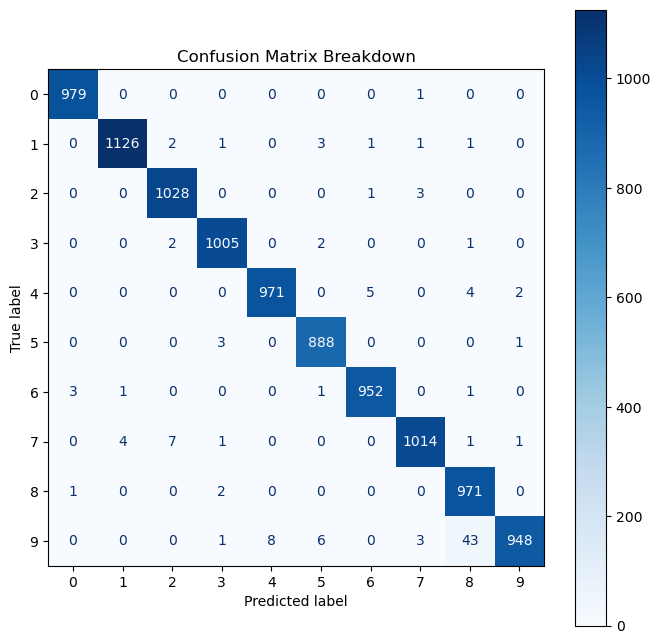

In [15]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

all_preds = []
all_labels = []

model.eval()
with torch.no_grad():
    for images, labels in testloader:
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=list(range(10)))

fig, ax = plt.subplots(figsize=(8, 8))
disp.plot(ax=ax, cmap='Blues', values_format='d')

plt.title('Confusion Matrix Breakdown')
plt.show()